## C-V Characteristic Modeling

1. import

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


from physics_loss import physics_loss
from phis_init import *
from Residual import *

from CVModeling import (
    G_phigd,
    Cjfet,
    Cgd,
    Cds,
    Cds_no_PT,
    Cgs,
)

2. Parameters

In [ ]:

# Device / numerical settings
device = "cpu"

dtype = torch.float32


# Surface-potential parameters

T = 300.0                         # K

NA = 1.0e16                      # cm^-3

ND = 5.0e16                      # cm^-3


# 4H-SiC parameters

Eg = 3.26                        # eV

eps_sic = (
    9.26
    * 8.854e-14
)                                # F/cm


# Approximation:
# Ec - Ei ≈ Eg / 2
Ec_minus_Ei = (
    Eg / 2.0
)


# Gate oxide

Cox = 7.0e-8                     # F/cm^2


# Fixed oxide charge
#
# Corresponds approximately to:
# Nox = 1e12 cm^-2

Qox = 1.602e-7                   # C/cm^2


# Flat-band voltage

Vfbs0 = -1.0                     # V


# Interface traps

Dit_mid = 2.0e11                 # cm^-2 eV^-1

Dit_edge = 2.0e13                # cm^-2 eV^-1

sigma_it = 0.1                   # eV


# Device geometry

Agd = 3.15e-2                    # cm^2

Ads = 2.97e-2                    # cm^2


# Punch-through voltage

Vpt = 500.0                      # V

# Cgd PINN training domain


VDG_MIN = 0.0
VDG_MAX = Vpt

VDS_GD_MIN = 0.0
VDS_GD_MAX = Vpt

# Cgd PINN training settings
N_TRAIN_GD = 6000

EPOCHS_GD = 4000

BATCH_SIZE_GD = 128

LEARNING_RATE_GD = 1.0e-4

TRAIN_CGD_PINN = False


# New checkpoint for positive-Vdg Cgd PINN

MODEL_CGD_PATH = (
    "phis_Cgd_Vdg_mixed_PINN.pth"
)

# Built-in potential

def calc_Vbi(
    ref,
    NA,
    ND,
    T,
    Eg,
):

    device_local = (
        ref.device
    )

    calc_dtype = (
        torch.float64
    )


    q_local = torch.as_tensor(
        1.602e-19,
        dtype=calc_dtype,
        device=device_local,
    )

    k_B_local = torch.as_tensor(
        1.381e-23,
        dtype=calc_dtype,
        device=device_local,
    )


    T_local = torch.as_tensor(
        T,
        dtype=calc_dtype,
        device=device_local,
    )

    NA_local = torch.as_tensor(
        NA,
        dtype=calc_dtype,
        device=device_local,
    )

    ND_local = torch.as_tensor(
        ND,
        dtype=calc_dtype,
        device=device_local,
    )


    ref_local = torch.zeros(
        1,
        dtype=calc_dtype,
        device=device_local,
    )


    ni_local = ni_4H_SiC(
        T_local,
        Eg,
        ref=ref_local,
    )


    Vt = (
        k_B_local
        * T_local
        / q_local
    )


    log_term = (
        torch.log(
            NA_local
        )
        + torch.log(
            ND_local
        )
        - 2.0
        * torch.log(
            ni_local
        )
    )


    Vbi_local = (
        Vt
        * log_term
    )


    return Vbi_local.to(
        dtype=ref.dtype,
        device=ref.device,
    )


# Gate-drain oxide capacitance

Coxgd = (
    Agd
    * Cox
)


# Cgs

Cgs_const = 1200e-12             # F

Add: PINN Network Duplication

In [ ]:
# Dedicated Cgd PINN
#
# Inputs:
#
#       Vdg
#       Vds
#
# Output:
#
#       delta_phi_gd
class DeltaPhiGdPINN(
    nn.Module
):

    def __init__(
        self
    ):

        super().__init__()


        self.net = nn.Sequential(

            nn.Linear(
                2,
                8
            ),

            nn.Tanh(),

            nn.Linear(
                8,
                1
            )
        )

        # Initial PINN correction = 0
        nn.init.zeros_(
            self.net[2].weight
        )

        nn.init.zeros_(
            self.net[2].bias
        )


    def forward(
        self,
        Vdg,
        Vds
    ):


        Vdg = Vdg.reshape(
            -1,
            1
        )


        Vds = Vds.reshape(
            -1,
            1
        )

        # Normalize Vdg
        #
        # [0, 500] -> [-1, 1]
        Vdg_norm = (

            2.0
            * (
                Vdg
                - VDG_MIN
            )
            / (
                VDG_MAX
                - VDG_MIN
            )
            - 1.0
        )

        # Normalize Vds
        #
        # [0, 500]->[-1, 1]
        Vds_norm = (

            2.0
            * (
                Vds
                - VDS_GD_MIN
            )
            / (
                VDS_GD_MAX
                - VDS_GD_MIN
            )
            - 1.0
        )

        # Neural-network input
        x = torch.cat(
            [
                Vdg_norm,
                Vds_norm
            ],
            dim=1
        )

        # PINN correction
        delta_phi_gd = (
            self.net(
                x
            )
        )


        return (
            delta_phi_gd
        )

Add: Load training results

In [4]:
# Load Cgd PINN
Model_Cgd = DeltaPhiGdPINN().to(
    device=device,
    dtype=dtype,
)

if TRAIN_CGD_PINN:

    raise RuntimeError(
        "TRAIN_CGD_PINN is False in the final notebook. "
        "Set it to True only if you want to retrain the Cgd PINN."
    )

else:

    state_dict_Cgd = torch.load(
        MODEL_CGD_PATH,
        map_location=device,
        weights_only=True,
    )

    Model_Cgd.load_state_dict(
        state_dict_Cgd,
        strict=True,
    )

    Model_Cgd.eval()

    print(
        "Loaded:",
        MODEL_CGD_PATH
    )

Loaded: phis_Cgd_Vdg_mixed_PINN.pth


3. C-V Voltage Sweep definition

In [5]:
# ============================================================
# C-V voltage sweep
# ============================================================

N_CV = 1001

Vds_cv = torch.linspace(
    0.0,
    1000.0,
    N_CV,
    dtype=dtype,
    device=device
).reshape(-1, 1)


# Measurement condition
VGS_CV = 0.0

Vgs_cv = torch.full_like(
    Vds_cv,
    VGS_CV
)

4. PT clamp for Cgd

In [6]:
# Build Vdg and apply PT clamp
Vdg_cv = (
    Vds_cv
    - Vgs_cv
)

Vdg_eff = torch.clamp(
    Vdg_cv,
    min=0.0,
    max=Vpt,
)

Vds_eff = torch.clamp(
    Vds_cv,
    min=0.0,
    max=Vpt,
)

In [7]:
# Predict phi_gd
@torch.no_grad()
def predict_phi_gd(
    model,
    Vdg,
    Vds,
):

    model.eval()

    Vdg = torch.as_tensor(
        Vdg,
        dtype=dtype,
        device=device,
    ).reshape(-1, 1)

    Vds = torch.as_tensor(
        Vds,
        dtype=dtype,
        device=device,
    ).reshape(-1, 1)

    phi_gd_init = phi_init(
        Vdg,
        Vds,
        T,
        NA,
        eps_sic,
        Cox,
        Vfbs0,
        Dit_mid,
        Dit_edge,
        sigma_it,
        Eg,
    ).reshape(-1, 1)

    delta_phi_gd = model(
        Vdg,
        Vds,
    )

    phi_gd = (
        phi_gd_init
        + delta_phi_gd
    )

    return phi_gd


phi_gd_CGD = predict_phi_gd(
    Model_Cgd,
    Vdg_eff,
    Vds_eff,
)

Calculate G(ϕgd) and CJFET, Cgd, Cds

In [ ]:
# Cds and Cgs

with torch.no_grad():

    # Built-in potential of PN junction

    Vbi_value = calc_Vbi(
        ref=Vds_cv,
        NA=NA,
        ND=ND,
        T=T,
        Eg=Eg,
    )


    # Output capacitance with punch-through treatment

    Cds_value = Cds(
        Vds_cv,
        ND,
        eps_sic,
        Ads,
        Vbi_value,
        Vpt,
    )


    # Output capacitance without punch-through treatment

    Cds_no_PT_value = Cds_no_PT(
        Vds_cv,
        ND,
        eps_sic,
        Ads,
        Vbi_value,
    )


    # Gate-source capacitance

    Cgs_value = Cgs(
        Vds_cv,
        Cgs_const,
    )

c:\Users\zipeng\Desktop\NNProject\Neural-Network_Internship_2026\.github\src\CVModeling.py:360: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than tensor.new_tensor(sourceTensor).
  Vbi_t = Vds.new_tensor(


F to pF

In [9]:
Cds_pF = (
    Cds_value
    * 1e12
)

Cds_no_PT_pF = (
    Cds_no_PT_value
    * 1e12
)

Cgs_pF = (
    Cgs_value
    * 1e12
)

10. Plot

In [10]:
# Compute Cgd
with torch.no_grad():

    G_gd_CGD = G_phigd(
        phi_gd_CGD,
        Vds_eff,
        T,
        NA,
        Eg,
    )

    CJFET_CGD = Cjfet(
        phi_gd_CGD,
        Vds_eff,
        T,
        NA,
        ND,
        Eg,
        eps_sic,
        Agd,
    )

    Cgd_CGD = Cgd(
        phi_gd_CGD,
        Vds_eff,
        T,
        NA,
        ND,
        Eg,
        eps_sic,
        Agd,
        Coxgd,
    )

CJFET_CGD_pF = (
    CJFET_CGD
    * 1e12
)

Cgd_CGD_pF = (
    Cgd_CGD
    * 1e12
)

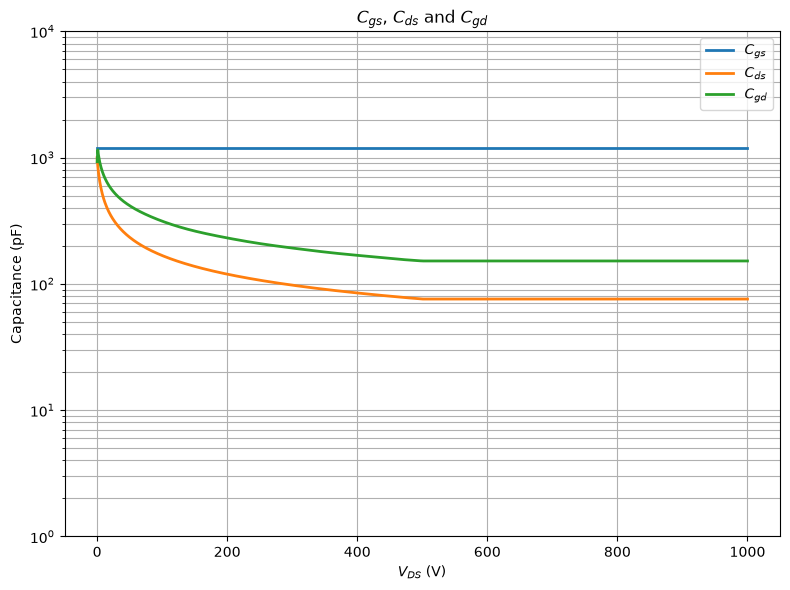

In [11]:
# Plot final capacitance curves
plt.figure(
    figsize=(8, 6)
)

plt.plot(
    Vds_cv.cpu().numpy(),
    Cgs_pF.cpu().numpy(),
    linewidth=2,
    label=r"$C_{gs}$",
)

plt.plot(
    Vds_cv.cpu().numpy(),
    Cds_pF.cpu().numpy(),
    linewidth=2,
    label=r"$C_{ds}$",
)

plt.plot(
    Vds_cv.cpu().numpy(),
    Cgd_CGD_pF.cpu().numpy(),
    linewidth=2,
    label=r"$C_{gd}$",
)

plt.xlabel(
    r"$V_{DS}$ (V)"
)

plt.ylabel(
    "Capacitance (pF)"
)

plt.title(
    r"$C_{gs}$, $C_{ds}$ and $C_{gd}$"
)

plt.yscale(
    "log"
)

plt.ylim(
    1,
    1e4
)

plt.grid(
    True,
    which="both"
)

plt.legend()

plt.tight_layout()

plt.show()